# 05 - Severity Distribution

**Purpose:** Identify the distribution that claim amounts follow, for each of the
four coverages. Candidate families are narrowed by the coefficient of variation,
skewness, and the mean excess plot, then ranked by AIC and BIC on maximum
likelihood fits, and the winner is confirmed with a QQ plot. No predictors are
involved; this is the marginal distribution only. Fitted on the claims table,
so the distribution is conditional on a claim having occurred.

**Input:** `data/processed/claims.csv`
**Output:** None. Conclusions carried into 07_SeverityModeling.
**Depends on:** 02_Cleaned_Data

**Candidates:** Gamma, Log-Normal, Weibull, Exponential, Pareto,
Inverse Gaussian

**Author:** Dalton | **Last run:** 2026-09-27


Setup

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
PROC = ROOT / "data" / "processed"
FIGS = ROOT / "outputs" / "figures"

claims = pd.read_csv(PROC / "claims.csv")
claims = claims.rename(columns={'class': 'class_year'})

COVERAGES = ['Personal Property', 'Additional Living Expense',
             'Guest Medical', 'Liability']

sv = {c: claims[claims.coverage == c].reset_index(drop=True) for c in COVERAGES}

{c: len(d) for c, d in sv.items()}

{'Personal Property': 973,
 'Additional Living Expense': 528,
 'Guest Medical': 233,
 'Liability': 85}

Distributions

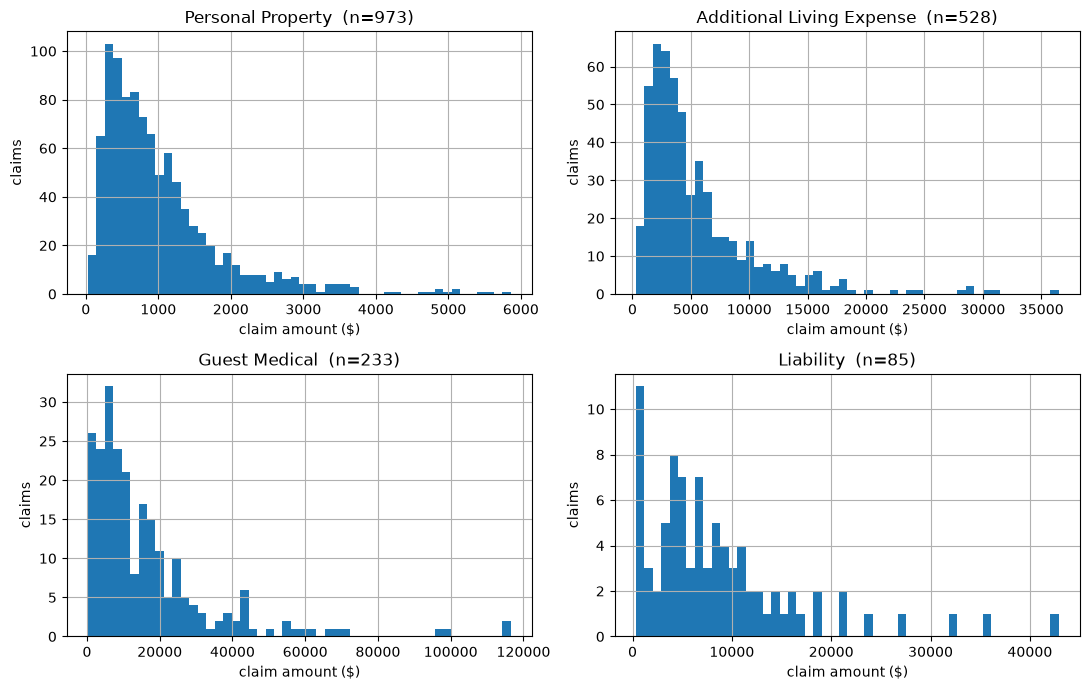

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, cov in zip(axes.flat, COVERAGES):
    d = sv[cov].amount
    d.hist(bins=50, ax=ax, color='#1f77b4')
    ax.set_title(f'{cov}  (n={len(d)})')
    ax.set_xlabel('claim amount ($)')
    ax.set_ylabel('claims')

plt.tight_layout()

Log-Histograms

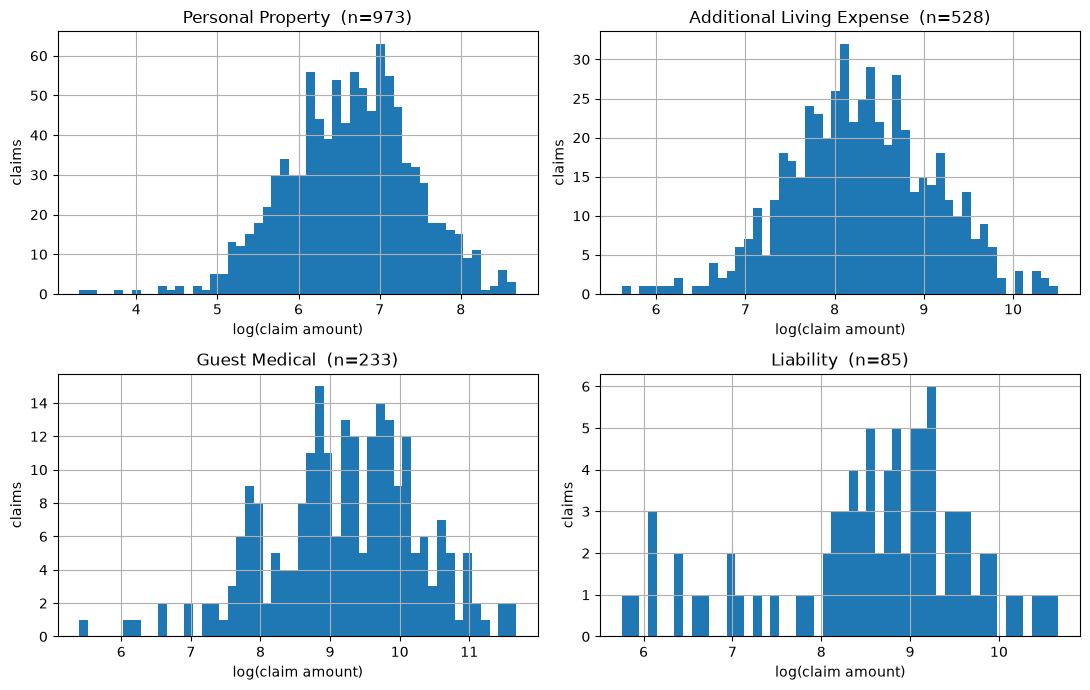

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, cov in zip(axes.flat, COVERAGES):
    d = sv[cov].amount
    np.log(d).hist(bins=50, ax=ax, color='#1f77b4')
    ax.set_title(f'{cov}  (n={len(d)})')
    ax.set_xlabel('log(claim amount)')
    ax.set_ylabel('claims')

plt.tight_layout()

Since these histograms all appear approximatley normal, we might think severity follows a lognormal distribution but further analysis of the BIC will be used to confirm

Our initial list of candidate distributions are Gamma, Log-Normal, Weibull, Exponenetial, inverse Gaussian, and Pareto


Starting With Personal Property

In [5]:
from scipy import stats

x = sv['Personal Property'].amount.values
n = len(x)

results = {}

for name, dist, k in [('LogNormal',   stats.lognorm,      2),
                      ('Gamma',       stats.gamma,        2),
                      ('Weibull',     stats.weibull_min,  2),
                      ('InvGaussian', stats.invgauss,     2),
                      ('Pareto',      stats.pareto,       2),
                      ('Exponential', stats.expon,        1)]:
    par = dist.fit(x, floc=0)                 # location fixed at 0, not estimated
    ll  = dist.logpdf(x, *par).sum()
    results[name] = (ll, k)

tbl = pd.DataFrame(
    [(name, ll, k, 2*k - 2*ll, k*np.log(n) - 2*ll)
     for name, (ll, k) in results.items()],
    columns=['distribution', 'loglik', 'k', 'AIC', 'BIC']
).sort_values('BIC')

tbl.round(2)

,distribution,loglik,k,AIC,BIC
0,LogNormal,-7604.99,2,15213.98,15223.74
1,Gamma,-7620.48,2,15244.96,15254.72
3,InvGaussian,-7636.77,2,15277.54,15287.30
2,Weibull,-7645.68,2,15295.37,15305.13
5,Exponential,-7716.45,1,15434.90,15439.78
4,Pareto,-8609.66,2,17223.33,17233.09


*Thus we will assume severity of personal property claims follows a LogNormal distribution

Now to analyze additional living expense

In [6]:
from scipy import stats

x = sv['Additional Living Expense'].amount.values
n = len(x)

results = {}

for name, dist, k in [('LogNormal',   stats.lognorm,      2),
                      ('Gamma',       stats.gamma,        2),
                      ('Weibull',     stats.weibull_min,  2),
                      ('InvGaussian', stats.invgauss,     2),
                      ('Pareto',      stats.pareto,       2),
                      ('Exponential', stats.expon,        1)]:
    par = dist.fit(x, floc=0)
    ll  = dist.logpdf(x, *par).sum()
    results[name] = (ll, k)

tbl = pd.DataFrame(
    [(name, ll, k, 2*k - 2*ll, k*np.log(n) - 2*ll)
     for name, (ll, k) in results.items()],
    columns=['distribution', 'loglik', 'k', 'AIC', 'BIC']
).sort_values('BIC')

tbl.round(2)

,distribution,loglik,k,AIC,BIC
0,LogNormal,-5015.67,2,10035.35,10043.88
3,InvGaussian,-5023.46,2,10050.91,10059.45
1,Gamma,-5035.75,2,10075.50,10084.03
2,Weibull,-5050.11,2,10104.23,10112.77
5,Exponential,-5076.73,1,10155.46,10159.73
4,Pareto,-5431.73,2,10867.46,10876.00


*Thus we will assume additional living expense severity follows lognormal

NOw to analyze Guest Medical

In [7]:
from scipy import stats

x = sv['Guest Medical'].amount.values
n = len(x)

results = {}

for name, dist, k in [('LogNormal',   stats.lognorm,      2),
                      ('Gamma',       stats.gamma,        2),
                      ('Weibull',     stats.weibull_min,  2),
                      ('InvGaussian', stats.invgauss,     2),
                      ('Pareto',      stats.pareto,       2),
                      ('Exponential', stats.expon,        1)]:
    par = dist.fit(x, floc=0)
    ll  = dist.logpdf(x, *par).sum()
    results[name] = (ll, k)

tbl = pd.DataFrame(
    [(name, ll, k, 2*k - 2*ll, k*np.log(n) - 2*ll)
     for name, (ll, k) in results.items()],
    columns=['distribution', 'loglik', 'k', 'AIC', 'BIC']
).sort_values('BIC')

tbl.round(2)

,distribution,loglik,k,AIC,BIC
0,LogNormal,-2492.95,2,4989.90,4996.80
5,Exponential,-2497.26,1,4996.53,4999.98
1,Gamma,-2496.17,2,4996.34,5003.24
2,Weibull,-2497.10,2,4998.20,5005.10
3,InvGaussian,-2513.08,2,5030.16,5037.06
4,Pareto,-2692.17,2,5388.33,5395.24


*thus we will assume Guest medical loss severity follows a LogNormal distribution

Now to analyze Liability

In [8]:
from scipy import stats

x = sv['Liability'].amount.values
n = len(x)

results = {}

for name, dist, k in [('LogNormal',   stats.lognorm,      2),
                      ('Gamma',       stats.gamma,        2),
                      ('Weibull',     stats.weibull_min,  2),
                      ('InvGaussian', stats.invgauss,     2),
                      ('Pareto',      stats.pareto,       2),
                      ('Exponential', stats.expon,        1)]:
    par = dist.fit(x, floc=0)
    ll  = dist.logpdf(x, *par).sum()
    results[name] = (ll, k)

tbl = pd.DataFrame(
    [(name, ll, k, 2*k - 2*ll, k*np.log(n) - 2*ll)
     for name, (ll, k) in results.items()],
    columns=['distribution', 'loglik', 'k', 'AIC', 'BIC']
).sort_values('BIC')

tbl.round(2)

,distribution,loglik,k,AIC,BIC
5,Exponential,-855.80,1,1713.60,1716.05
1,Gamma,-854.72,2,1713.44,1718.33
2,Weibull,-854.77,2,1713.55,1718.43
0,LogNormal,-860.73,2,1725.46,1730.35
3,InvGaussian,-869.57,2,1743.13,1748.02
4,Pareto,-905.99,2,1815.98,1820.86


Interestingly, Liabilty follows an exponential as opposed to lognormal, so we will move foward with that assumption